In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


1.Problem Statement:

Developed a machine learning model to estimate health insurance premiums based on customer attributes.

Independent variables:
1. Age
2. Gender
3. Hieght
4. weight
5. Health Insurance Cover

    


Dependent Variable:

Premium


2. Data Gathring:


In [ ]:
df = pd.read_excel('height_weight_data.xlsx')
df

,Sr.no,Name,Age(yrs),Gender,Height (cm),Weight(kg),Health Insurance cover,Premium
0,1,krushna,0.250000,male,61.4,6.4,500000,7015
1,2,pavan,0.333333,male,63.9,7.0,500000,7015
2,3,ketan,0.416667,male,65.9,7.5,500000,7015
3,4,akash,0.500000,male,67.6,7.9,500000,7015
4,5,syam,0.583333,male,69.2,8.3,500000,7015
...,...,...,...,...,...,...,...,...
1671,1672,kiran,81.000000,female,155.0,NaN,10000000,111340
1672,1673,mira,82.000000,female,155.0,65.0,10000000,111340
1673,1674,radha,83.000000,female,155.0,65.0,10000000,111340
1674,1675,lakshmi,84.000000,female,155.0,65.0,10000000,111340


3. Exploratory Data Analysis:






1. Checking Missing values:

In [ ]:
df.isna().sum()

,0
Sr.no,0
Name,0
Age(yrs),0
Gender,0
Height (cm),7
Weight(kg),6
Health Insurance cover,0
Premium,0


In [ ]:
#The dataset contains missing values in two independent variables.
#There are 7 missing values in Height and 6 in Weight, which will be handled using mean or median imputation

2.  Checking for object column in dataset to encode:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sr.no                   1676 non-null   int64  
 1   Name                    1676 non-null   object 
 2   Age(yrs)                1676 non-null   float64
 3   Gender                  1676 non-null   object 
 4   Height (cm)             1669 non-null   float64
 5   Weight(kg)              1670 non-null   float64
 6   Health Insurance cover  1676 non-null   int64  
 7   Premium                 1676 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 104.9+ KB


In [ ]:
#The dataset contains two object-type columns: Gender and Name. Only the Gender column will be encoded.

3. detecting outliers in the datasets:

<Axes: xlabel='Age(yrs)'>

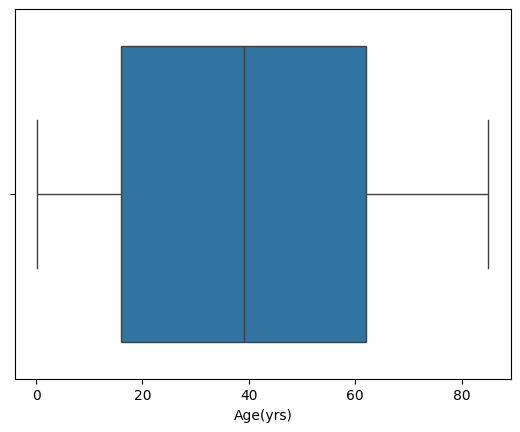

In [ ]:
# Using Boxplot:

sns.boxplot(x=df['Age(yrs)'])

In [ ]:
#using Zscore:
#z_score = (Xi - Xmean)/Xstd

In [ ]:
def zscore_age(col):
  outliers =[]
  for i in col:
    zscore =(i-col.mean())/col.std()
    if zscore>3or zscore<-3:
      outliers.append(i)
  return outliers
zscore_age(df['Age(yrs)'])

<>:5: SyntaxWarning: invalid decimal literal
<>:5: SyntaxWarning: invalid decimal literal
/tmp/ipykernel_17163/529088025.py:5: SyntaxWarning: invalid decimal literal
  if zscore>3or zscore<-3:


[]

In [ ]:
# we are not having outliers in age column.

In [ ]:
#Using IQR:

q1 = df['Height (cm)'].quantile(.25)
q2 = df['Height (cm)'].quantile(.50)
q3 = df['Height (cm)'].quantile(.75)

iqr = q3-q1
lower_tale = q1-1.5*iqr
upper_tale = q3+1.5*iqr

print("Lower tale :",lower_tale)
print("Upper tale :",upper_tale)





Lower tale : 137.00000000000003
Upper tale : 181.79999999999998


<Axes: xlabel='Height (cm)'>

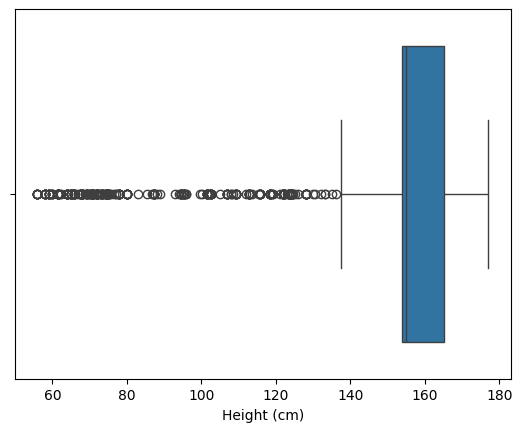

In [ ]:
sns.boxplot(x=df['Height (cm)'])

In [ ]:
# We are having outliers in Height column,we'll handle these outliers in feature engineering.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sr.no                   1676 non-null   int64  
 1   Name                    1676 non-null   object 
 2   Age(yrs)                1676 non-null   float64
 3   Gender                  1676 non-null   object 
 4   Height (cm)             1669 non-null   float64
 5   Weight(kg)              1670 non-null   float64
 6   Health Insurance cover  1676 non-null   int64  
 7   Premium                 1676 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 104.9+ KB


<Axes: ylabel='Weight(kg)'>

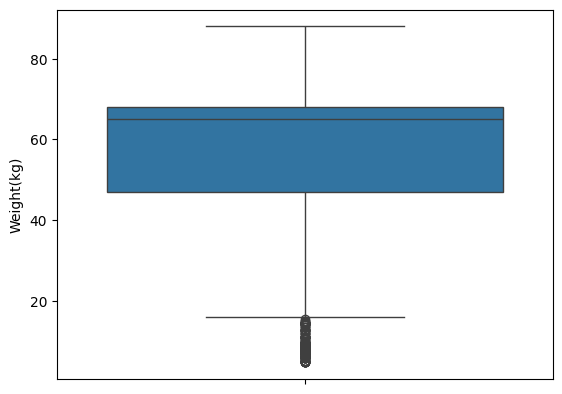

In [ ]:
sns.boxplot(df['Weight(kg)'])

In [ ]:
# We are having outliers in Weight column, we'll handle these outliers in feature engineering.


4. Feature Engineering:

In [ ]:
# Filling missing/null values :
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sr.no                   1676 non-null   int64  
 1   Name                    1676 non-null   object 
 2   Age(yrs)                1676 non-null   float64
 3   Gender                  1676 non-null   object 
 4   Height (cm)             1669 non-null   float64
 5   Weight(kg)              1670 non-null   float64
 6   Health Insurance cover  1676 non-null   int64  
 7   Premium                 1676 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 104.9+ KB


In [ ]:
df['Height (cm)'].isna().sum()

df['Height (cm)'].median()

df['Height (cm)'].fillna(df['Height (cm)'].median(), inplace=True)




/tmp/ipykernel_17163/757982864.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Height (cm)'].fillna(df['Height (cm)'].median(), inplace=True)


In [ ]:
df['Height (cm)'].isna().sum()

np.int64(0)

In [ ]:
df['Weight(kg)'].isna().sum()

np.int64(6)

In [ ]:
df['Weight(kg)'].fillna(df['Weight(kg)'].median(), inplace=True)

df.isna().sum()

/tmp/ipykernel_17163/3556953422.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight(kg)'].fillna(df['Weight(kg)'].median(), inplace=True)


,0
Sr.no,0
Name,0
Age(yrs),0
Gender,0
Height (cm),0
Weight(kg),0
Health Insurance cover,0
Premium,0


In [ ]:
# Performing encoding over df['Gender'] feature :

In [ ]:
df['Gender'].unique()


array(['male', 'female'], dtype=object)

In [ ]:
df['Gender'].replace({'male':0, 'female':1}, inplace=True)

/tmp/ipykernel_17163/2855755960.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'male':0, 'female':1}, inplace=True)
/tmp/ipykernel_17163/2855755960.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].replace({'male':0, 'female':1}, inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sr.no                   1676 non-null   int64  
 1   Name                    1676 non-null   object 
 2   Age(yrs)                1676 non-null   float64
 3   Gender                  1676 non-null   object 
 4   Height (cm)             1676 non-null   float64
 5   Weight(kg)              1676 non-null   float64
 6   Health Insurance cover  1676 non-null   int64  
 7   Premium                 1676 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 104.9+ KB


In [ ]:
df['BMI'] = df['Weight(kg)']/((df['Height (cm)']/100)**2)

df

,Sr.no,Name,Age(yrs),Gender,Height (cm),Weight(kg),Health Insurance cover,Premium,BMI
0,1,krushna,0.250000,male,61.4,6.4,500000,7015,16.976307
1,2,pavan,0.333333,male,63.9,7.0,500000,7015,17.143375
2,3,ketan,0.416667,male,65.9,7.5,500000,7015,17.269924
3,4,akash,0.500000,male,67.6,7.9,500000,7015,17.287560
4,5,syam,0.583333,male,69.2,8.3,500000,7015,17.332687
...,...,...,...,...,...,...,...,...,...
1671,1672,kiran,81.000000,female,155.0,65.0,10000000,111340,27.055151
1672,1673,mira,82.000000,female,155.0,65.0,10000000,111340,27.055151
1673,1674,radha,83.000000,female,155.0,65.0,10000000,111340,27.055151
1674,1675,lakshmi,84.000000,female,155.0,65.0,10000000,111340,27.055151


<Axes: xlabel='BMI'>

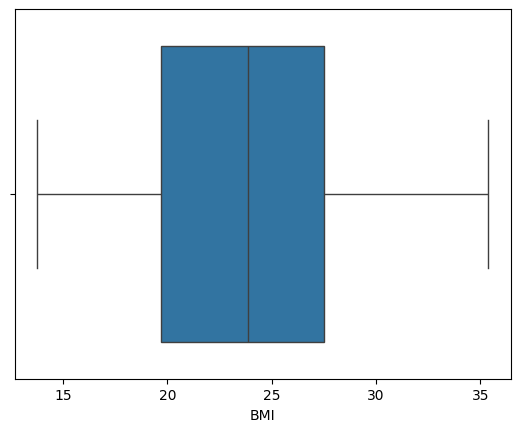

In [ ]:
sns.boxplot(x=df['BMI'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sr.no                   1676 non-null   int64  
 1   Name                    1676 non-null   object 
 2   Age(yrs)                1676 non-null   float64
 3   Gender                  1676 non-null   object 
 4   Height (cm)             1676 non-null   float64
 5   Weight(kg)              1676 non-null   float64
 6   Health Insurance cover  1676 non-null   int64  
 7   Premium                 1676 non-null   int64  
 8   BMI                     1676 non-null   float64
dtypes: float64(4), int64(3), object(2)
memory usage: 118.0+ KB


In [ ]:
df.drop(['Sr.no', 'Name', 'Height (cm)', 'Weight(kg)'], axis=1, inplace=True)

df


,Age(yrs),Gender,Health Insurance cover,Premium,BMI
0,0.250000,male,500000,7015,16.976307
1,0.333333,male,500000,7015,17.143375
2,0.416667,male,500000,7015,17.269924
3,0.500000,male,500000,7015,17.287560
4,0.583333,male,500000,7015,17.332687
...,...,...,...,...,...
1671,81.000000,female,10000000,111340,27.055151
1672,82.000000,female,10000000,111340,27.055151
1673,83.000000,female,10000000,111340,27.055151
1674,84.000000,female,10000000,111340,27.055151


5. Feature Selection:

<Axes: >

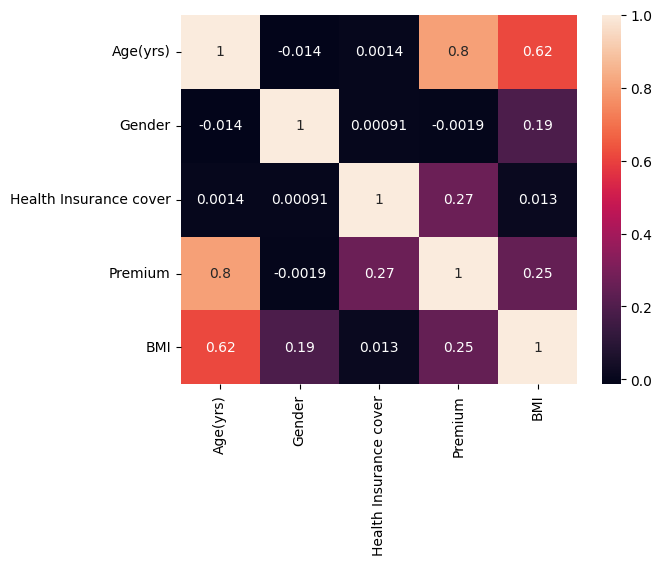

In [ ]:
sns.heatmap(df.corr(), annot=True)

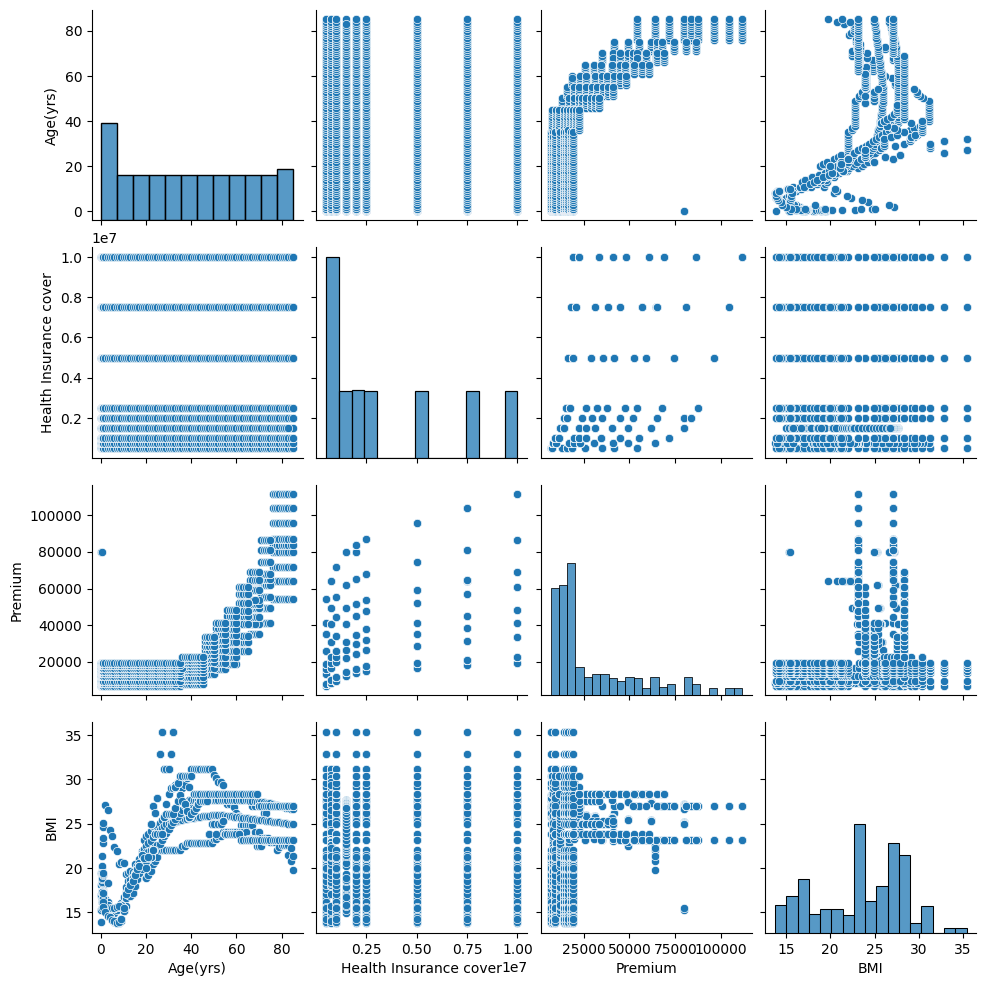

In [ ]:
sns.pairplot(df)

6. model Building:

In [ ]:
x = df.drop('Premium', axis=1)
y = df['Premium']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=1)


1. Linear Regression

#Model Evaluation

In [ ]:
# testing Accuracy:

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error :",mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error :",rmse)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error :",mae)

r2 = r2_score(y_test, y_pred)
print("R2 Score :",r2)




Mean Squared Error : 103828434.46981017
Root Mean Squared Error : 10189.623863019193
Mean Absolute Error : 7900.433844436255
R2 Score : 0.8324585751408807


In [ ]:
#training accuracy:

y_pred_train = linear_model.predict(x_train)

mse = mean_squared_error(y_train, y_pred_train)
print("Mean Squared Error :",mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error :",rmse)

mae = mean_absolute_error(y_train, y_pred_train)
print("Mean Absolute Error :",mae)

r2 = r2_score(y_train, y_pred_train)
print("R2 Score :",r2)




Mean Squared Error : 115514230.08867213
Root Mean Squared Error : 10747.75465335305
Mean Absolute Error : 8150.092927382705
R2 Score : 0.8219894882209786


2. Decision Tree:

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=1)

# Model Evaluation :

In [ ]:
# testing accuracy :
y_pred = dt_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error :",mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error :",rmse)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error :",mae)

r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)


Mean Squared Error : 197624.25447316104
Root Mean Squared Error : 444.5494960891993
Mean Absolute Error : 28.031809145129223
R2 Score : 0.9996811061502542


In [ ]:
#training accuracy :
y_pred_train = dt_model.predict(x_train)

mse = mean_squared_error(y_train, y_pred_train)
print("Mean Squared Error :",mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error :",rmse)

mae = mean_absolute_error(y_train, y_pred_train)
print("Mean Absolute Error :",mae)

r2 = r2_score(y_train, y_pred_train)
print("R2 Score :", r2)

Mean Squared Error : 0.0
Root Mean Squared Error : 0.0
Mean Absolute Error : 0.0
R2 Score : 1.0


3. Random Forest :

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=1)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=10)
rf_model.fit(x_train, y_train)


RandomForestRegressor(random_state=10)

# Model Evaluation :

In [ ]:
# testing accuracy :
y_pred = rf_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error :",mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error :",rmse)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error :",mae)

r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)


Mean Squared Error : 1910128.9930666
Root Mean Squared Error : 1382.074163374238
Mean Absolute Error : 234.4931411530814
R2 Score : 0.996917744789303


In [ ]:
 #training accuracy :
y_pred_train = rf_model.predict(x_train)

mse = mean_squared_error(y_train, y_pred_train)
print("Mean Squared Error :",mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error :",rmse)

mae = mean_absolute_error(y_train, y_pred_train)
print("Mean Absolute Error :",mae)

r2 = r2_score(y_train, y_pred_train)
print("R2 Score :", r2)


Mean Squared Error : 902738.5378623188
Root Mean Squared Error : 950.1255379487064
Mean Absolute Error : 131.46005967604424
R2 Score : 0.9986088558179874


In [ ]:
df

,Age(yrs),Gender,Health Insurance cover,Premium,BMI
0,0.250000,0,500000,7015,16.976307
1,0.333333,0,500000,7015,17.143375
2,0.416667,0,500000,7015,17.269924
3,0.500000,0,500000,7015,17.287560
4,0.583333,0,500000,7015,17.332687
...,...,...,...,...,...
1671,81.000000,1,10000000,111340,27.055151
1672,82.000000,1,10000000,111340,27.055151
1673,83.000000,1,10000000,111340,27.055151
1674,84.000000,1,10000000,111340,27.055151


In [ ]:
#Testing Model by taking data from user :

age = 32
gender = 'female'
health_insurance_cover = 5000000
height = 152
weight = 51

In [ ]:
def gender_encoder(gender):
  if gender=='male':
    return 0
  else:
    return 1

    gender_encoder('female')

def bmi_converter(ht, wt):
  bmi = wt/((ht/100)**2)
  return bmi

bmi_converter(167, 55)

19.721036967980208

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age(yrs)                1676 non-null   float64
 1   Gender                  1676 non-null   int64  
 2   Health Insurance cover  1676 non-null   int64  
 3   Premium                 1676 non-null   int64  
 4   BMI                     1676 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 65.6 KB


In [ ]:
test_df = pd.DataFrame({'Age(yrs)':[age],
                        'Gender':[gender_encoder(gender)],
                        'Health Insurance cover':[health_insurance_cover],
                        'BMI':[bmi_converter(height, weight)]})

In [ ]:
test_df
rf_model.predict(test_df)

array([16795.])

In [ ]:
 #pickling the model :
import pickle
file = open('rf_model_file.pkl', 'wb')
pickle.dump(rf_model, file)
file.close()


In [ ]:
# Unpicking the file :

f = open('rf_model_file.pkl', 'rb')
rf_new_model = pickle.load(f)
f.close()

rf_new_model.predict(test_df)

array([16795.])